<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/Dia_homework_finished.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
dia = pd.read_csv('diabetes.csv')
dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [3]:
dia.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [4]:
dia.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1
1999,2,81,72,15,76,30.1,0.547,25,0


In [5]:
dia.shape

(2000, 9)

In [6]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [7]:
dia.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [8]:
dia.duplicated().sum()

np.int64(1256)

In [9]:
dup_view = dia[dia.duplicated(keep=False)].sort_values(by=['Age','BMI'])
print(dup_view.head(10))

      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
60              2       84              0              0        0   0.0   
145             0      102             75             23        0   0.0   
371             0      118             64             23       89   0.0   
841             0      118             64             23       89   0.0   
1303            0      102             75             23        0   0.0   
1624            0      118             64             23       89   0.0   
1881            2       84              0              0        0   0.0   
1966            0      102             75             23        0   0.0   
438             1       97             70             15        0  18.2   
908             1       97             70             15        0  18.2   

      DiabetesPedigreeFunction  Age  Outcome  
60                       0.304   21        0  
145                      0.572   21        0  
371                      1.731   

In [10]:
dia = dia.drop_duplicates()
dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1564,1,100,62,0,0,64.4,0.152,36,0
1565,0,163,40,23,64,40.7,0.322,33,0
1566,6,139,84,37,0,50.7,0.320,50,1
1567,2,167,44,30,140,52.7,0.452,28,0


In [11]:
cols_with_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
dia[cols_with_zeros]=dia[cols_with_zeros].replace(0,np.nan)


In [12]:
dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35.0,NaN,33.6,0.127,47,1
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
2,0,145.0,NaN,NaN,NaN,44.2,0.630,31,1
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1564,1,100.0,62.0,NaN,NaN,64.4,0.152,36,0
1565,0,163.0,40.0,23.0,64.0,40.7,0.322,33,0
1566,6,139.0,84.0,37.0,NaN,50.7,0.320,50,1
1567,2,167.0,44.0,30.0,140.0,52.7,0.452,28,0


In [13]:
for cols in cols_with_zeros:
  dia[cols] = dia[cols].fillna(dia[cols].median())

In [14]:
dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35.0,126.0,33.6,0.127,47,1
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
2,0,145.0,72.0,29.0,126.0,44.2,0.630,31,1
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1564,1,100.0,62.0,29.0,126.0,64.4,0.152,36,0
1565,0,163.0,40.0,23.0,64.0,40.7,0.322,33,0
1566,6,139.0,84.0,37.0,126.0,50.7,0.320,50,1
1567,2,167.0,44.0,30.0,140.0,52.7,0.452,28,0


In [15]:
dia.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,3.752688,121.678763,72.250000,29.288978,140.333333,32.665188,0.472355,33.142473,0.340054
std,3.335541,30.356124,12.047321,9.390932,82.294741,7.292025,0.326181,11.751286,0.474046
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,25.000000,121.500000,27.600000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,126.000000,32.400000,0.375500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,130.000000,36.800000,0.632500,40.250000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [16]:
X = dia.drop(columns=['Outcome'])
y=dia['Outcome']

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled,y_train)

LogisticRegression()

In [20]:
from sklearn.metrics import accuracy_score,classification_report
y_pred = model.predict(X_test_scaled)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("n\Classification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.7651006711409396
n\Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.83        98
           1       0.72      0.51      0.60        51

    accuracy                           0.77       149
   macro avg       0.75      0.70      0.72       149
weighted avg       0.76      0.77      0.75       149



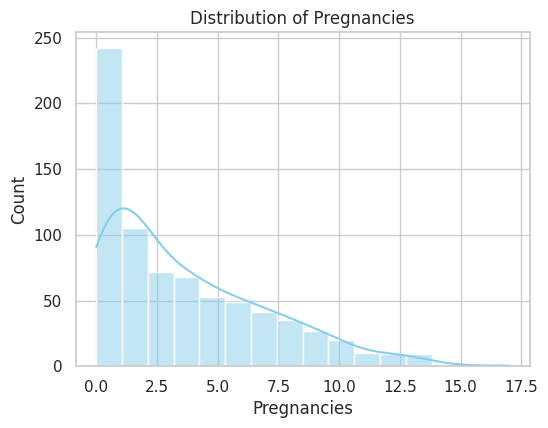

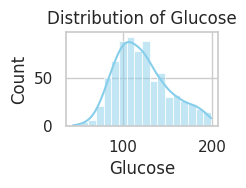

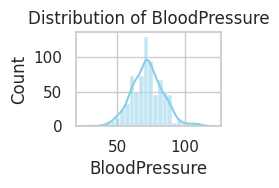

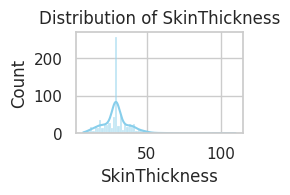

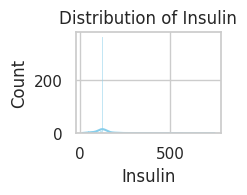

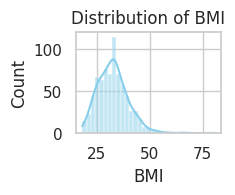

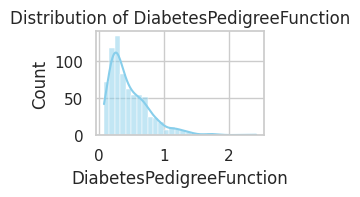

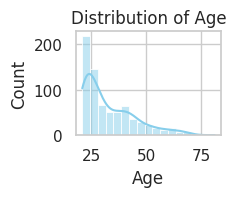

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15,12))
features = X.columns
for i, col in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.histplot(dia[col],kde=True,color="skyblue")
  plt.title(f'Distribution of {col}')
  plt.tight_layout()
  plt.show()

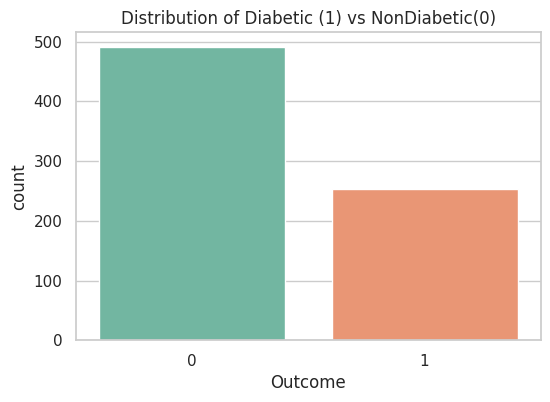

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome',data=dia,palette="Set2")
plt.title('Distribution of Diabetic (1) vs NonDiabetic(0)')
plt.show()


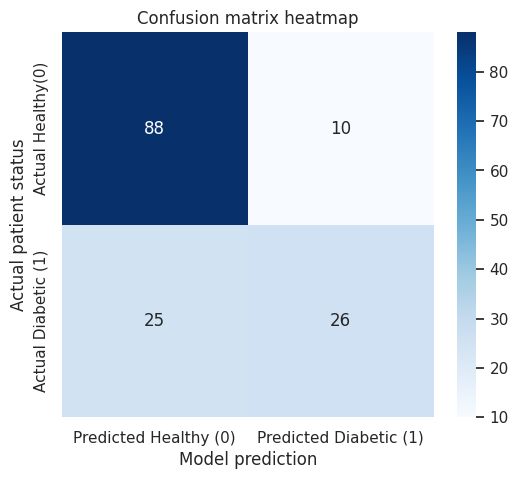

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Healthy (0)','Predicted Diabetic (1)'],
            yticklabels=['Actual Healthy(0)','Actual Diabetic (1)'])
plt.ylabel('Actual patient status')
plt.xlabel('Model prediction')
plt.title('Confusion matrix heatmap')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

In [25]:
dia = pd.read_csv('diabetes.csv')

In [26]:
duplicate_count = dia.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

Number of exact duplicate rows: 1256


In [27]:
dia_clean = dia.drop_duplicates()
print(f"Dataset size after removing duplicates: {dia_clean.shape[0]} rows")

Dataset size after removing duplicates: 744 rows


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

dia = pd.read_csv('diabetes.csv')

dia = dia.drop_duplicates()

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    dia[col] = dia[col].replace(0, np.nan)
dia = dia.dropna()

X = dia.drop(columns=['Outcome'])
y = dia['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

configs = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15]}
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.05, 0.1, 0.2]}
    }
}

for model_name, config in configs.items():
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    print(f"\n" + "="*50)
    print(f" {model_name} (Fixed Data)")
    print(f" Best Settings: {grid_search.best_params_}")
    print("="*50)

    y_pred = grid_search.best_estimator_.predict(X_test)
    print(classification_report(y_test, y_pred))



 Decision Tree (Fixed Data)
 Best Settings: {'max_depth': 3, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.79      0.88      0.84        52
           1       0.68      0.52      0.59        25

    accuracy                           0.77        77
   macro avg       0.74      0.70      0.71        77
weighted avg       0.76      0.77      0.76        77


 Random Forest (Fixed Data)
 Best Settings: {'max_depth': 15, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        52
           1       0.72      0.52      0.60        25

    accuracy                           0.78        77
   macro avg       0.76      0.71      0.73        77
weighted avg       0.77      0.78      0.77        77


 XGBoost (Fixed Data)
 Best Settings: {'learning_rate': 0.1, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.75      0.92     

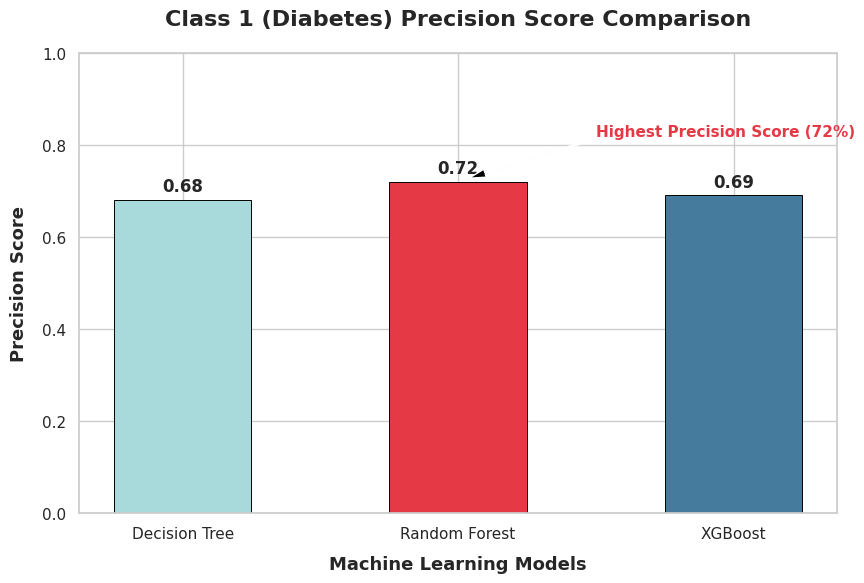

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Decision Tree', 'Random Forest', 'XGBoost']
precision_scores = [0.68, 0.72, 0.69]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

colors = ['#A8DADC', '#E63946', '#457B9D']
bars = plt.bar(models, precision_scores, color=colors, width=0.5, edgecolor='black', linewidth=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Class 1 (Diabetes) Precision Score Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Machine Learning Models', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Precision Score', fontsize=13, fontweight='bold', labelpad=10)
plt.ylim(0, 1.0)

plt.annotate('Highest Precision Score (72%)',
             xy=(1, 0.72),
             xytext=(1.5, 0.82),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=11, fontweight='bold', color='#E63946')

plt.tight_layout()
plt.show()
